In [26]:
!pip -q install kagglehub opencv-python-headless scikit-image --upgrade

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.7/13.7 MB 89.5 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
cucim-cu12 26.2.1 requires scikit-image<0.26.0,>=0.19.0, but you have scikit-image 0.26.0 which is incompatible.


In [27]:
import os, time, random, json
import numpy as np
import pandas as pd
import cv2
import matplotlib.pyplot as plt
from skimage.feature import hog

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import EfficientNetB0

from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report
)
from sklearn.utils.class_weight import compute_class_weight

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("TensorFlow:", tf.__version__)
print("GPU available:", tf.config.list_physical_devices("GPU"))


TensorFlow: 2.20.0
GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [28]:
KAGGLE_NATIVE_PATH = "/kaggle/input/skin-cancer9-classesisic"

if os.path.exists(KAGGLE_NATIVE_PATH):
    print("Running inside a Kaggle notebook — using the attached dataset directly.")
    base_path = KAGGLE_NATIVE_PATH
else:
    print("Not on Kaggle — downloading dataset via kagglehub.")
    import kagglehub
    base_path = kagglehub.dataset_download("nodoubttome/skin-cancer9-classesisic")

DATASET_ROOT = os.path.join(
    base_path, "Skin cancer ISIC The International Skin Imaging Collaboration"
)
TRAIN_DIR = os.path.join(DATASET_ROOT, "Train")
TEST_DIR = os.path.join(DATASET_ROOT, "Test")

print("Train dir:", TRAIN_DIR)
print("Test dir:", TEST_DIR)

Not on Kaggle — downloading dataset via kagglehub.
Using Colab cache for faster access to the 'skin-cancer9-classesisic' dataset.
Train dir: /kaggle/input/skin-cancer9-classesisic/Skin cancer ISIC The International Skin Imaging Collaboration/Train
Test dir: /kaggle/input/skin-cancer9-classesisic/Skin cancer ISIC The International Skin Imaging Collaboration/Test


In [29]:

SELECTED_CLASSES = [
    "pigmented benign keratosis",
    "melanoma",
    "nevus",
    "basal cell carcinoma",
    "squamous cell carcinoma",
]
NUM_CLASSES = len(SELECTED_CLASSES)
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
IMAGE_EXTENSIONS = (".jpg", ".jpeg", ".png")


def get_image_paths_and_labels(folder, selected_classes):
    image_paths, labels = [], []
    for label, class_name in enumerate(selected_classes):
        class_folder = os.path.join(folder, class_name)
        for file_name in os.listdir(class_folder):
            if file_name.lower().endswith(IMAGE_EXTENSIONS):
                image_paths.append(os.path.join(class_folder, file_name))
                labels.append(label)
    return image_paths, labels


train_paths, train_labels = get_image_paths_and_labels(TRAIN_DIR, SELECTED_CLASSES)
test_paths, test_labels = get_image_paths_and_labels(TEST_DIR, SELECTED_CLASSES)

train_paths_split, val_paths, train_labels_split, val_labels = train_test_split(
    train_paths, train_labels, test_size=0.20, random_state=SEED, stratify=train_labels
)

print("Training images:", len(train_paths_split))
print("Validation images:", len(val_paths))
print("Testing images:", len(test_paths))


def create_dataframe(image_paths, labels):
    return pd.DataFrame({
        "filename": image_paths,
        "class": [SELECTED_CLASSES[l] for l in labels],
        "label": labels,
    })


train_df = create_dataframe(train_paths_split, train_labels_split)
val_df = create_dataframe(val_paths, val_labels)
test_df = create_dataframe(test_paths, test_labels)

class_weights_array = compute_class_weight(
    class_weight="balanced", classes=np.unique(train_labels_split), y=train_labels_split
)
class_weights = {i: float(w) for i, w in enumerate(class_weights_array)}
print("Class weights:", class_weights)

Training images: 1451
Validation images: 363
Testing images: 80
Class weights: {0: 0.786449864498645, 1: 0.8291428571428572, 2: 1.0146853146853148, 3: 0.9641196013289036, 4: 2.0013793103448276}


In [30]:
def load_gray(path, size=IMG_SIZE):
    img = cv2.imread(path)
    if img is None:
        raise FileNotFoundError(f"Could not read image: {path}")
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, size)
    gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
    return img, gray


def sobel_x(gray, ksize=3):
    g = cv2.Sobel(gray, cv2.CV_64F, 1, 0, ksize=ksize)
    return cv2.convertScaleAbs(g)

def sobel_y(gray, ksize=3):
    g = cv2.Sobel(gray, cv2.CV_64F, 0, 1, ksize=ksize)
    return cv2.convertScaleAbs(g)

def sobel_magnitude(gray, ksize=3):
    gx = cv2.Sobel(gray, cv2.CV_64F, 1, 0, ksize=ksize)
    gy = cv2.Sobel(gray, cv2.CV_64F, 0, 1, ksize=ksize)
    mag = cv2.magnitude(gx, gy)
    return cv2.convertScaleAbs(mag)

def prewitt(gray):
    kx = np.array([[-1, 0, 1], [-1, 0, 1], [-1, 0, 1]], dtype=np.float32)
    ky = np.array([[-1, -1, -1], [0, 0, 0], [1, 1, 1]], dtype=np.float32)
    gx = cv2.filter2D(gray.astype(np.float32), -1, kx)
    gy = cv2.filter2D(gray.astype(np.float32), -1, ky)
    mag = cv2.magnitude(gx, gy)
    return cv2.convertScaleAbs(mag)


def laplacian(gray, ksize=3):
    lap = cv2.Laplacian(gray, cv2.CV_64F, ksize=ksize)
    return cv2.convertScaleAbs(lap)

def log_edge(gray, gauss_ksize=5, sigma=1.0, lap_ksize=3):
    blurred = cv2.GaussianBlur(gray, (gauss_ksize, gauss_ksize), sigma)
    lap = cv2.Laplacian(blurred, cv2.CV_64F, ksize=lap_ksize)
    return cv2.convertScaleAbs(lap)

def canny_edge(gray, low=50, high=150, kernel_size=3):
    blurred = cv2.GaussianBlur(gray, (kernel_size, kernel_size), 0)
    return cv2.Canny(blurred, low, high)


EDGE_METHODS = {
    "Sobel (Gx)": sobel_x,
    "Sobel (Gy)": sobel_y,
    "Sobel (magnitude)": sobel_magnitude,
    "Prewitt": prewitt,
    "Laplacian": laplacian,
    "LoG": log_edge,
    "Canny": canny_edge,
}
print("Edge methods ready:", list(EDGE_METHODS.keys()))

Edge methods ready: ['Sobel (Gx)', 'Sobel (Gy)', 'Sobel (magnitude)', 'Prewitt', 'Laplacian', 'LoG', 'Canny']


In [31]:

REPRESENTATIVE_CLASSES = ["melanoma", "nevus", "basal cell carcinoma"]

sample_paths = {}
for cls in REPRESENTATIVE_CLASSES:
    p = train_df.loc[train_df["class"] == cls, "filename"].iloc[0]
    sample_paths[cls] = p

print(sample_paths)

{'melanoma': '/kaggle/input/skin-cancer9-classesisic/Skin cancer ISIC The International Skin Imaging Collaboration/Train/melanoma/ISIC_0010866.jpg', 'nevus': '/kaggle/input/skin-cancer9-classesisic/Skin cancer ISIC The International Skin Imaging Collaboration/Train/nevus/ISIC_0000409.jpg', 'basal cell carcinoma': '/kaggle/input/skin-cancer9-classesisic/Skin cancer ISIC The International Skin Imaging Collaboration/Train/basal cell carcinoma/ISIC_0028419.jpg'}


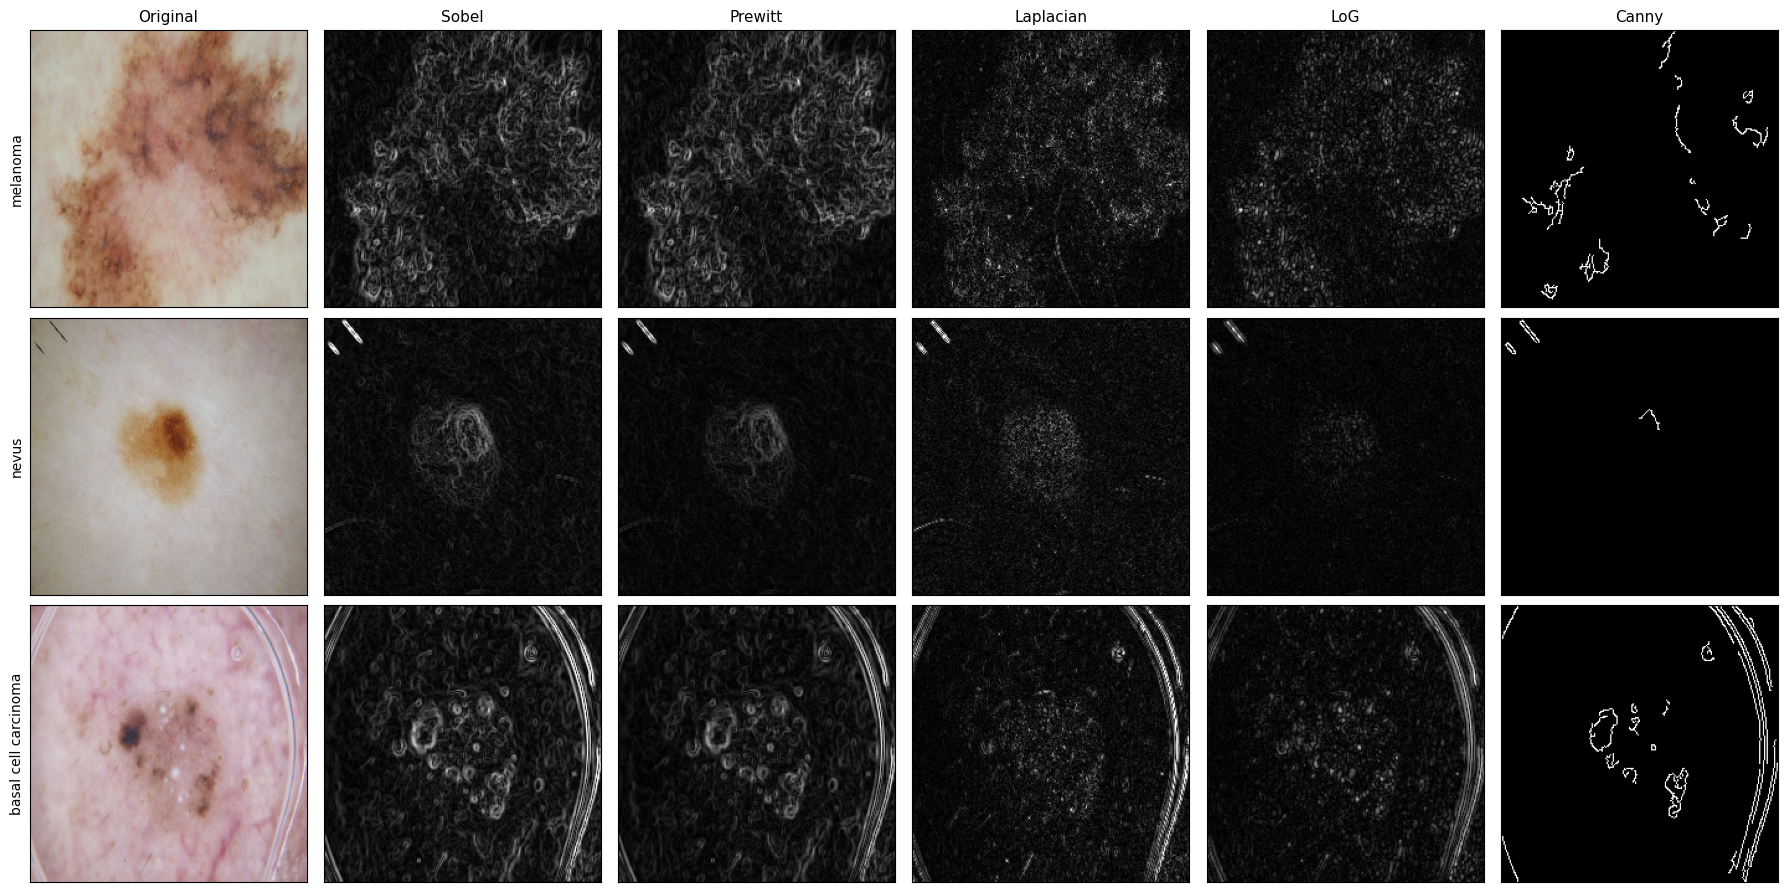

In [32]:

fig, axes = plt.subplots(len(REPRESENTATIVE_CLASSES), 6, figsize=(18, 3 * len(REPRESENTATIVE_CLASSES)))

col_titles = ["Original", "Sobel", "Prewitt", "Laplacian", "LoG", "Canny"]

for row, cls in enumerate(REPRESENTATIVE_CLASSES):
    rgb, gray = load_gray(sample_paths[cls])
    results = [
        rgb,
        sobel_magnitude(gray),
        prewitt(gray),
        laplacian(gray),
        log_edge(gray),
        canny_edge(gray),
    ]
    for col, (title, img) in enumerate(zip(col_titles, results)):
        ax = axes[row, col]
        cmap = None if col == 0 else "gray"
        ax.imshow(img, cmap=cmap)
        if row == 0:
            ax.set_title(title, fontsize=11)
        if col == 0:
            ax.set_ylabel(cls, fontsize=10)
        ax.set_xticks([]); ax.set_yticks([])

plt.tight_layout()
plt.savefig("task1_edge_comparison.png", dpi=150)
plt.show()

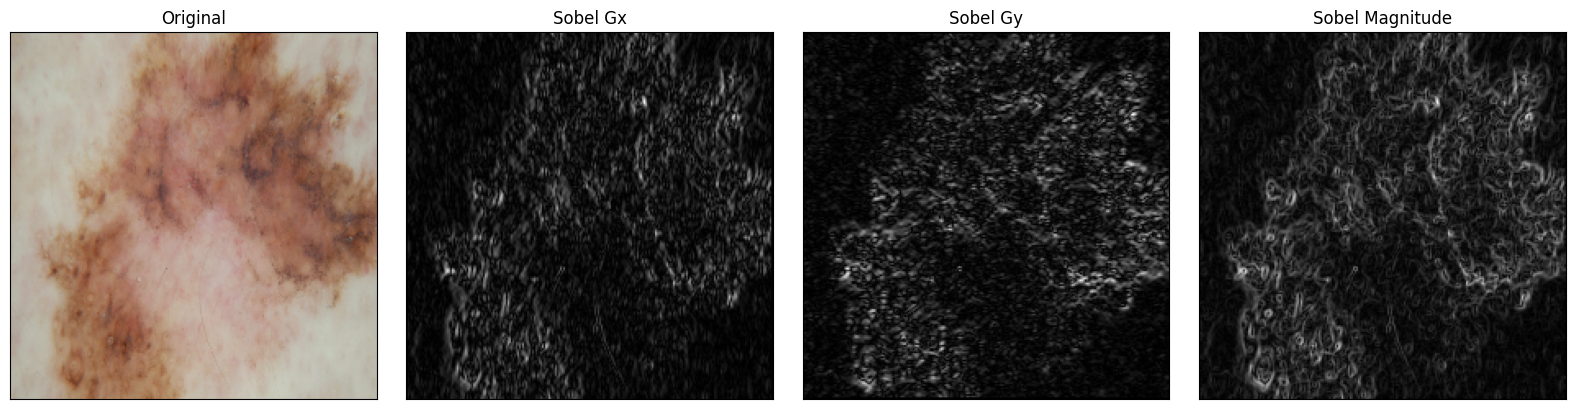

In [33]:

rgb, gray = load_gray(sample_paths[REPRESENTATIVE_CLASSES[0]])
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for ax, (title, img) in zip(axes, [
    ("Original", rgb), ("Sobel Gx", sobel_x(gray)),
    ("Sobel Gy", sobel_y(gray)), ("Sobel Magnitude", sobel_magnitude(gray))
]):
    ax.imshow(img, cmap=None if title == "Original" else "gray")
    ax.set_title(title); ax.set_xticks([]); ax.set_yticks([])
plt.tight_layout()
plt.savefig("task1_sobel_components.png", dpi=150)
plt.show()

Task:02

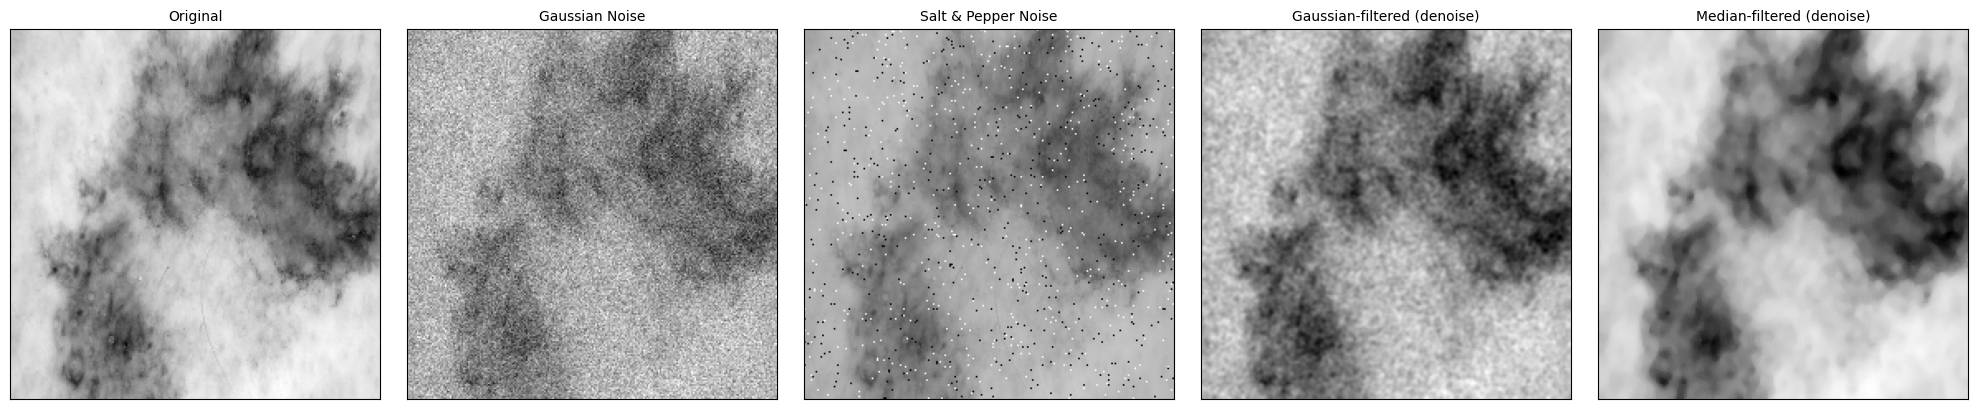

In [34]:
def add_gaussian_noise(img, mean=0, sigma=25):
    noise = np.random.normal(mean, sigma, img.shape).astype(np.float32)
    noisy = img.astype(np.float32) + noise
    return np.clip(noisy, 0, 255).astype(np.uint8)


def add_salt_pepper_noise(img, amount=0.02, salt_vs_pepper=0.5):
    noisy = img.copy()
    num_salt = int(np.ceil(amount * img.size * salt_vs_pepper))
    num_pepper = int(np.ceil(amount * img.size * (1.0 - salt_vs_pepper)))

    coords = [np.random.randint(0, i, num_salt) for i in img.shape[:2]]
    noisy[coords[0], coords[1]] = 255

    coords = [np.random.randint(0, i, num_pepper) for i in img.shape[:2]]
    noisy[coords[0], coords[1]] = 0
    return noisy


def gaussian_denoise(img, ksize=5, sigma=1.0):
    return cv2.GaussianBlur(img, (ksize, ksize), sigma)


def median_denoise(img, ksize=5):
    return cv2.medianBlur(img, ksize)


sample_path = sample_paths[REPRESENTATIVE_CLASSES[0]]
_, gray_clean = load_gray(sample_path)

gray_noisy_gauss = add_gaussian_noise(gray_clean)
gray_noisy_sp = add_salt_pepper_noise(gray_clean)
gray_denoised_gauss = gaussian_denoise(gray_noisy_gauss)
gray_denoised_median = median_denoise(gray_noisy_sp)

fig, axes = plt.subplots(1, 5, figsize=(20, 4))
for ax, (t, im) in zip(axes, [
    ("Original", gray_clean), ("Gaussian Noise", gray_noisy_gauss),
    ("Salt & Pepper Noise", gray_noisy_sp),
    ("Gaussian-filtered (denoise)", gray_denoised_gauss),
    ("Median-filtered (denoise)", gray_denoised_median),
]):
    ax.imshow(im, cmap="gray"); ax.set_title(t, fontsize=10); ax.set_xticks([]); ax.set_yticks([])
plt.tight_layout()
plt.savefig("task2_noise_examples.png", dpi=150)
plt.show()

In [35]:
def edge_density(edge_img):
    """Fraction of pixels classified as edges — simple, reproducible quality/sensitivity proxy."""
    binary = (edge_img > 0).astype(np.uint8) if edge_img.max() <= 1 else (edge_img > 30).astype(np.uint8)
    return binary.sum() / binary.size


def edge_continuity_score(edge_img):
    """Ratio of edge pixels that lie in the largest connected component — higher = more
    continuous edges, lower = more broken/fragmented edges."""
    binary = (edge_img > 30).astype(np.uint8)
    n_labels, labels_im = cv2.connectedComponents(binary)
    if n_labels <= 1:
        return 0.0
    sizes = [np.sum(labels_im == i) for i in range(1, n_labels)]
    return max(sizes) / max(binary.sum(), 1)


baseline_density = {name: edge_density(fn(gray_clean)) for name, fn in EDGE_METHODS.items()}

conditions = [
    ("Sobel", "Original", "None", "None", gray_clean),
    ("Sobel", "Noisy", "Gaussian", "None", gray_noisy_gauss),
    ("Sobel", "Noisy", "Salt & Pepper", "None", gray_noisy_sp),
    ("Sobel", "Noisy", "Gaussian", "Gaussian Filter", gaussian_denoise(gray_noisy_gauss)),
    ("Sobel", "Noisy", "Salt & Pepper", "Median Filter", median_denoise(gray_noisy_sp)),
    ("Prewitt", "Original", "None", "None", gray_clean),
    ("Laplacian", "Original", "None", "None", gray_clean),
    ("LoG", "Noisy", "Gaussian", "Gaussian Filter", gaussian_denoise(gray_noisy_gauss)),
    ("Canny", "Original", "None", "Built-in smoothing", gray_clean),
    ("Canny", "Noisy", "Gaussian", "Gaussian Filter", gaussian_denoise(gray_noisy_gauss)),
    ("Canny", "Noisy", "Salt & Pepper", "Median Filter", median_denoise(gray_noisy_sp)),
]

method_fn = {
    "Sobel": sobel_magnitude, "Prewitt": prewitt, "Laplacian": laplacian,
    "LoG": log_edge, "Canny": canny_edge,
}

rows = []
for detector, input_type, noise_type, prep, img in conditions:
    edge_img = method_fn[detector](img)
    density = edge_density(edge_img)
    continuity = edge_continuity_score(edge_img)
    sensitivity_pct = 100 * (density - baseline_density[
        {"Sobel": "Sobel (magnitude)"}.get(detector, detector)
    ]) / max(baseline_density.get({"Sobel": "Sobel (magnitude)"}.get(detector, detector), 1e-6), 1e-6)
    rows.append({
        "Edge Detector": detector, "Input Image": input_type, "Noise Type": noise_type,
        "Preprocessing": prep,
        "Edge Quality (continuity)": round(continuity, 3),
        "Noise Sensitivity (% change in edge density vs. clean)": round(sensitivity_pct, 1),
        "Observations": "",  # fill in qualitatively after visually inspecting the plots above
    })

table1_df = pd.DataFrame(rows)
table1_df

,Edge Detector,Input Image,Noise Type,Preprocessing,Edge Quality (continuity),Noise Sensitivity (% change in edge density vs. clean),Observations
0,Sobel,Original,None,None,0.905,0.0,
1,Sobel,Noisy,Gaussian,None,1.000,164.5,
2,Sobel,Noisy,Salt & Pepper,None,0.827,26.8,
3,Sobel,Noisy,Gaussian,Gaussian Filter,0.995,88.1,
4,Sobel,Noisy,Salt & Pepper,Median Filter,0.260,-47.3,
5,Prewitt,Original,None,None,0.361,0.0,
6,Laplacian,Original,None,None,0.101,0.0,
7,LoG,Noisy,Gaussian,Gaussian Filter,0.008,209.4,
8,Canny,Original,None,Built-in smoothing,0.153,0.0,
9,Canny,Noisy,Gaussian,Gaussian Filter,0.182,18.4,


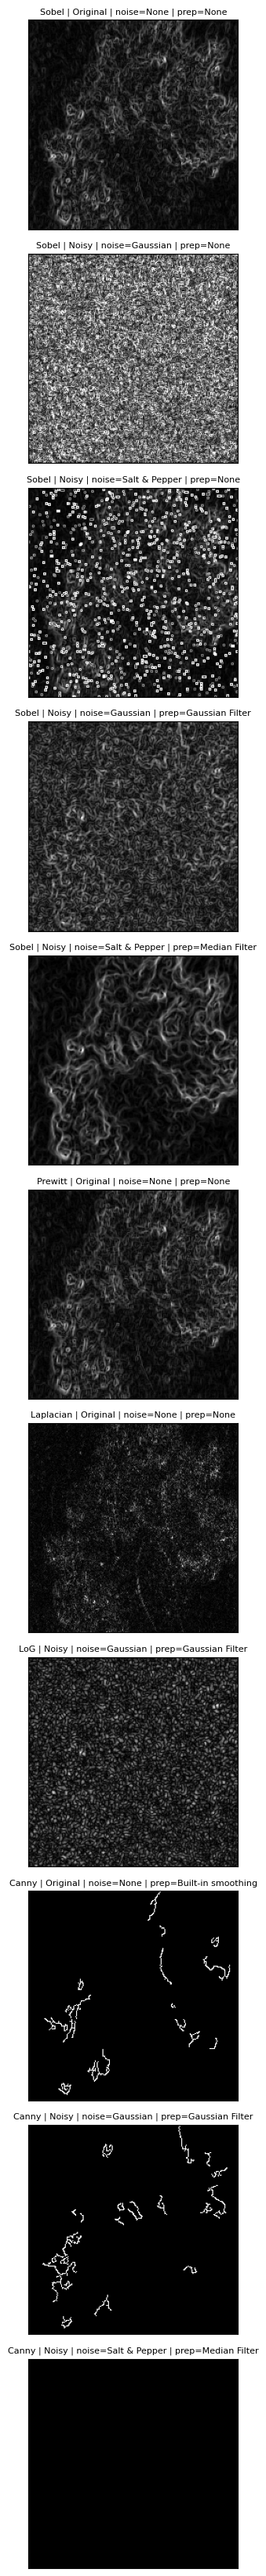

In [36]:

fig, axes = plt.subplots(len(conditions), 1, figsize=(4, 3 * len(conditions)))
for ax, (detector, input_type, noise_type, prep, img) in zip(axes, conditions):
    edge_img = method_fn[detector](img)
    ax.imshow(edge_img, cmap="gray")
    ax.set_title(f"{detector} | {input_type} | noise={noise_type} | prep={prep}", fontsize=8)
    ax.set_xticks([]); ax.set_yticks([])
plt.tight_layout()
plt.savefig("task2_table1_edge_maps.png", dpi=150)
plt.show()


Task:03

In [37]:
canny_configs = [
    ("Canny-1", 30, 100, 3),
    ("Canny-2", 50, 150, 3),
    ("Canny-3", 100, 200, 3),
    ("Canny-4", 50, 150, 5),   # same thresholds as Canny-2, larger Gaussian kernel
]

rows = []
canny_results_imgs = {}
for name, low, high, ksize in canny_configs:
    edge_img = canny_edge(gray_clean, low=low, high=high, kernel_size=ksize)
    canny_results_imgs[name] = edge_img
    n_edges = int((edge_img > 0).sum())
    quality = edge_continuity_score(edge_img)
    rows.append({
        "Configuration": name, "Low Threshold": low, "High Threshold": high,
        "Kernel Size": f"{ksize}x{ksize}", "Edge Quality (continuity)": round(quality, 3),
        "Number of Detected Edges": n_edges, "Observation": "",
    })

table2_df = pd.DataFrame(rows)
table2_df


,Configuration,Low Threshold,High Threshold,Kernel Size,Edge Quality (continuity),Number of Detected Edges,Observation
0,Canny-1,30,100,3x3,0.058,3185,
1,Canny-2,50,150,3x3,0.153,752,
2,Canny-3,100,200,3x3,0.000,0,
3,Canny-4,50,150,5x5,0.471,85,


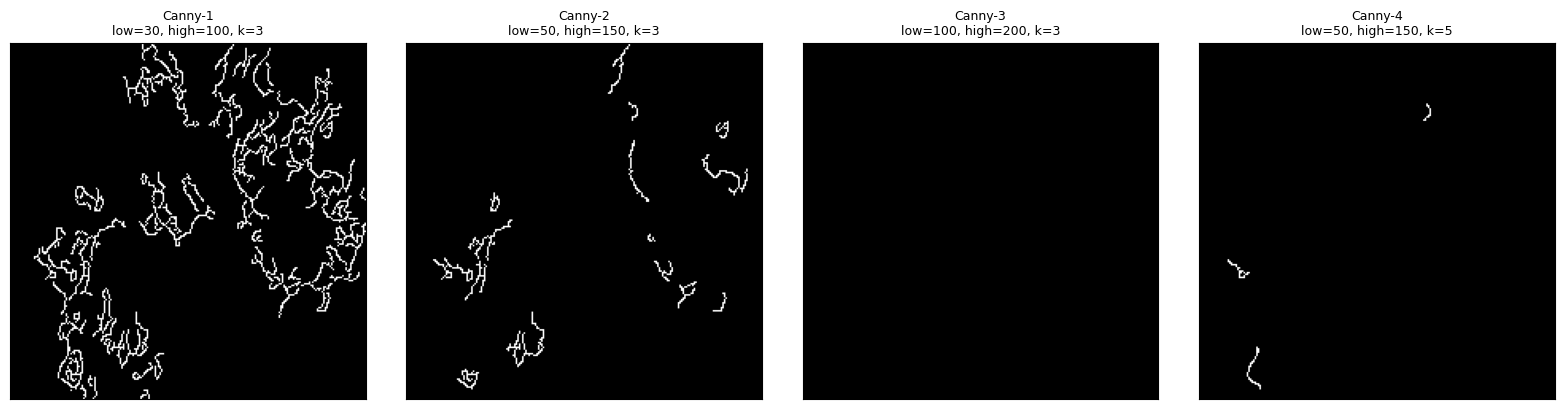

In [38]:
fig, axes = plt.subplots(1, len(canny_configs), figsize=(4 * len(canny_configs), 4))
for ax, (name, low, high, ksize) in zip(axes, canny_configs):
    ax.imshow(canny_results_imgs[name], cmap="gray")
    ax.set_title(f"{name}\nlow={low}, high={high}, k={ksize}", fontsize=9)
    ax.set_xticks([]); ax.set_yticks([])
plt.tight_layout()
plt.savefig("task3_canny_params.png", dpi=150)
plt.show()


In [39]:

densities = {name: (canny_results_imgs[name] > 0).mean() for name, *_ in canny_configs}
candidates = {name: q for name, q in zip(table2_df["Configuration"], table2_df["Edge Quality (continuity)"])
              if 0.01 < densities[name] < 0.25}
BEST_CANNY_NAME = max(candidates, key=candidates.get) if candidates else table2_df.iloc[1]["Configuration"]
BEST_CANNY_CFG = next(c for c in canny_configs if c[0] == BEST_CANNY_NAME)

print(f"Selected best Canny configuration: {BEST_CANNY_NAME} "
      f"(low={BEST_CANNY_CFG[1]}, high={BEST_CANNY_CFG[2]}, kernel={BEST_CANNY_CFG[3]}x{BEST_CANNY_CFG[3]})")
print("Re-run this cell after inspecting the images above; override BEST_CANNY_NAME manually if you disagree.")


Selected best Canny configuration: Canny-2 (low=50, high=150, kernel=3x3)
Re-run this cell after inspecting the images above; override BEST_CANNY_NAME manually if you disagree.


Task:04

In [40]:
BEST_LAB2_FILTER = "Gaussian"

def apply_mean_filter(img, ksize=5):
    return cv2.blur(img, (ksize, ksize))

def apply_gaussian_filter(img, ksize=5, sigma=1.0):
    return cv2.GaussianBlur(img, (ksize, ksize), sigma)

def apply_median_filter(img, ksize=5):
    return cv2.medianBlur(img, ksize)

def apply_sharpen_filter(img):
    kernel = np.array([[0, -1, 0], [-1, 5, -1], [0, -1, 0]])
    return cv2.filter2D(img, -1, kernel)

LAB2_FILTERS = {
    "Average": apply_mean_filter, "Gaussian": apply_gaussian_filter,
    "Median": apply_median_filter, "Sharpen": apply_sharpen_filter,
}
best_filter_fn = LAB2_FILTERS[BEST_LAB2_FILTER]


def make_raw(img_rgb):
    return img_rgb

def make_filtered(img_rgb):
    return best_filter_fn(img_rgb)

def make_edge(img_rgb):
    gray = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2GRAY)
    _, low, high, ksize = BEST_CANNY_CFG
    edges = canny_edge(gray, low=low, high=high, kernel_size=ksize)
    return cv2.cvtColor(edges, cv2.COLOR_GRAY2RGB)


DATASET_VARIANTS = {"Raw": make_raw, "Filtered": make_filtered, "Edge": make_edge}


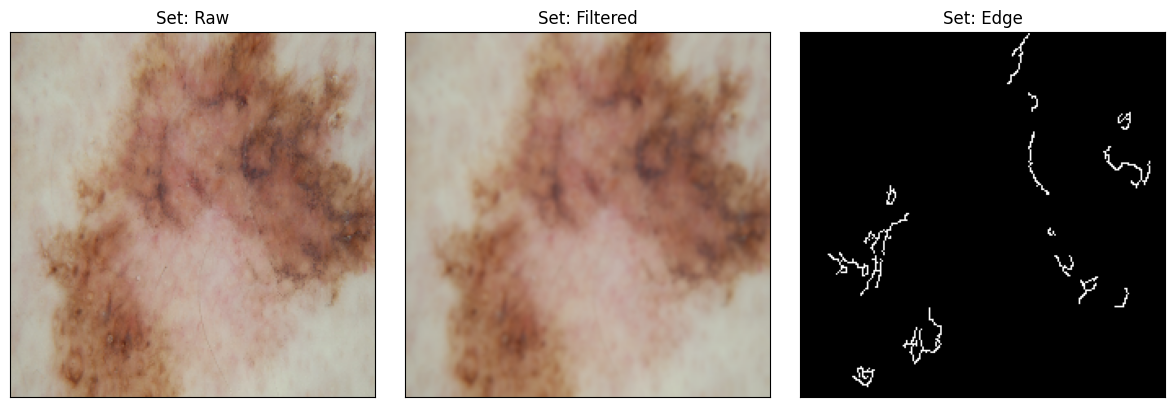

In [41]:

rgb_sample, _ = load_gray(sample_path)
fig, axes = plt.subplots(1, 3, figsize=(12, 4))
for ax, (name, fn) in zip(axes, DATASET_VARIANTS.items()):
    out = fn(rgb_sample)
    ax.imshow(out); ax.set_title(f"Set: {name}"); ax.set_xticks([]); ax.set_yticks([])
plt.tight_layout()
plt.savefig("task4_dataset_variants.png", dpi=150)
plt.show()


In [42]:
def make_keras_generators(variant_fn):
    def preprocess(img):
        img = np.clip(img, 0, 255).astype(np.uint8)
        out = variant_fn(img)
        return out.astype(np.float32) / 255.0

    train_datagen = ImageDataGenerator(
        preprocessing_function=preprocess, rotation_range=20, width_shift_range=0.15,
        height_shift_range=0.15, shear_range=0.15, zoom_range=0.15,
        horizontal_flip=True, fill_mode="nearest",
    )
    val_test_datagen = ImageDataGenerator(preprocessing_function=preprocess)

    train_gen = train_datagen.flow_from_dataframe(
        train_df, x_col="filename", y_col="class", target_size=IMG_SIZE,
        batch_size=BATCH_SIZE, class_mode="categorical", classes=SELECTED_CLASSES,
        shuffle=True, seed=SEED,
    )
    val_gen = val_test_datagen.flow_from_dataframe(
        val_df, x_col="filename", y_col="class", target_size=IMG_SIZE,
        batch_size=BATCH_SIZE, class_mode="categorical", classes=SELECTED_CLASSES,
        shuffle=False,
    )
    test_gen = val_test_datagen.flow_from_dataframe(
        test_df, x_col="filename", y_col="class", target_size=IMG_SIZE,
        batch_size=BATCH_SIZE, class_mode="categorical", classes=SELECTED_CLASSES,
        shuffle=False,
    )
    return train_gen, val_gen, test_gen


In [43]:

def extract_hog_features(paths, variant_fn, size=(128, 128)):
    feats = []
    for p in paths:
        img = cv2.imread(p)
        if img is None:
            raise FileNotFoundError(f"Could not read image: {p}")
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img = cv2.resize(img, size)
        out = variant_fn(img)
        gray = cv2.cvtColor(out, cv2.COLOR_RGB2GRAY) if out.ndim == 3 else out
        f = hog(gray, orientations=9, pixels_per_cell=(16, 16), cells_per_block=(2, 2))
        feats.append(f)
    return np.array(feats)

In [44]:
def build_cnn_model1(input_shape=(224, 224, 3), num_classes=NUM_CLASSES):
    """CNN Model 1 — small CNN trained from scratch."""
    model = keras.Sequential([
        layers.Input(shape=input_shape),
        layers.Conv2D(32, 3, activation="relu"), layers.MaxPooling2D(),
        layers.Conv2D(64, 3, activation="relu"), layers.MaxPooling2D(),
        layers.Conv2D(128, 3, activation="relu"), layers.MaxPooling2D(),
        layers.GlobalAveragePooling2D(),
        layers.Dense(128, activation="relu"),
        layers.Dropout(0.4),
        layers.Dense(num_classes, activation="softmax"),
    ], name="CNN_Model1_scratch")
    model.compile(optimizer=keras.optimizers.Adam(1e-3),
                  loss="categorical_crossentropy", metrics=["accuracy"])
    return model


def build_cnn_model2(input_shape=(224, 224, 3), num_classes=NUM_CLASSES):
    """CNN Model 2 — EfficientNetB0 transfer learning (the best backbone from Lab 01)."""
    base = EfficientNetB0(weights="imagenet", include_top=False, input_shape=input_shape)
    base.trainable = False
    model = keras.Sequential([
        base, layers.GlobalAveragePooling2D(), layers.Dropout(0.3),
        layers.Dense(256, activation="relu"), layers.Dropout(0.3),
        layers.Dense(num_classes, activation="softmax"),
    ], name="CNN_Model2_EfficientNetB0")
    model.compile(optimizer=keras.optimizers.Adam(1e-4),
                  loss="categorical_crossentropy", metrics=["accuracy"])
    return model

In [45]:
def train_and_eval_keras(model_builder, train_gen, val_gen, test_gen, epochs=8):
    model = model_builder()
    callbacks = [
        keras.callbacks.EarlyStopping(monitor="val_loss", patience=3, restore_best_weights=True),
        keras.callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=2, min_lr=1e-6),
    ]
    t0 = time.time()
    model.fit(train_gen, validation_data=val_gen, epochs=epochs,
              class_weight=class_weights, callbacks=callbacks, verbose=1)
    train_time = time.time() - t0

    test_gen.reset()
    t0 = time.time()
    y_prob = model.predict(test_gen, verbose=0)
    infer_time_ms = 1000 * (time.time() - t0) / len(test_gen.classes)

    y_pred = np.argmax(y_prob, axis=1)
    y_true = test_gen.classes
    return _metrics_dict(y_true, y_pred, train_time, infer_time_ms), confusion_matrix(y_true, y_pred)


def train_and_eval_sklearn(clf, X_train, y_train, X_test, y_test):
    t0 = time.time()
    clf.fit(X_train, y_train)
    train_time = time.time() - t0

    t0 = time.time()
    y_pred = clf.predict(X_test)
    infer_time_ms = 1000 * (time.time() - t0) / len(y_test)

    return _metrics_dict(y_test, y_pred, train_time, infer_time_ms), confusion_matrix(y_test, y_pred)


def _metrics_dict(y_true, y_pred, train_time, infer_time_ms):
    return {
        "Accuracy": accuracy_score(y_true, y_pred) * 100,
        "Precision": precision_score(y_true, y_pred, average="macro", zero_division=0) * 100,
        "Recall": recall_score(y_true, y_pred, average="macro", zero_division=0) * 100,
        "F1-Score": f1_score(y_true, y_pred, average="macro", zero_division=0) * 100,
        "Training Time (s)": train_time,
        "Inference Time (ms)": infer_time_ms,
    }


Task:04

In [20]:
EPOCHS = 8

results = {}
conf_matrices = {}

train_labels_arr = np.array(train_df["label"])
test_labels_arr = np.array(test_df["label"])

for variant_name, variant_fn in DATASET_VARIANTS.items():
    print(f"\n{'='*70}\nDataset variant: {variant_name}\n{'='*70}")

    # ---- Classical ML on HOG features ----
    X_train = extract_hog_features(train_df["filename"].tolist(), variant_fn)
    X_test = extract_hog_features(test_df["filename"].tolist(), variant_fn)

    for clf_name, clf in [
        ("SVM", SVC(kernel="rbf", class_weight="balanced")),
        ("Random Forest", RandomForestClassifier(n_estimators=200, random_state=SEED, class_weight="balanced")),
        ("KNN", KNeighborsClassifier(n_neighbors=5)),
    ]:
        print(f"Training {clf_name} on {variant_name} features...")
        metrics, cm = train_and_eval_sklearn(clf, X_train, train_labels_arr, X_test, test_labels_arr)
        results[(clf_name, variant_name)] = metrics
        conf_matrices[(clf_name, variant_name)] = cm


    train_gen, val_gen, test_gen = make_keras_generators(variant_fn)
    for model_name, builder in [
        ("CNN Model 1", build_cnn_model1),
        ("CNN Model 2", build_cnn_model2),
    ]:
        print(f"Training {model_name} on {variant_name} images...")
        metrics, cm = train_and_eval_keras(builder, train_gen, val_gen, test_gen, epochs=EPOCHS)
        results[(model_name, variant_name)] = metrics
        conf_matrices[(model_name, variant_name)] = cm

print("\nAll experiments complete.")


Dataset variant: Raw
Training SVM on Raw features...
Training Random Forest on Raw features...
Training KNN on Raw features...
Found 1451 validated image filenames belonging to 5 classes.
Found 363 validated image filenames belonging to 5 classes.
Found 80 validated image filenames belonging to 5 classes.
Training CNN Model 1 on Raw images...
Epoch 1/8
46/46 ━━━━━━━━━━━━━━━━━━━━ 47s 856ms/step - accuracy: 0.2371 - loss: 1.6013 - val_accuracy: 0.2700 - val_loss: 1.5437 - learning_rate: 0.0010
Epoch 2/8
46/46 ━━━━━━━━━━━━━━━━━━━━ 35s 769ms/step - accuracy: 0.3336 - loss: 1.4355 - val_accuracy: 0.1901 - val_loss: 1.5686 - learning_rate: 0.0010
Epoch 3/8
46/46 ━━━━━━━━━━━━━━━━━━━━ 34s 744ms/step - accuracy: 0.3384 - loss: 1.3377 - val_accuracy: 0.3223 - val_loss: 1.2623 - learning_rate: 0.0010
Epoch 4/8
46/46 ━━━━━━━━━━━━━━━━━━━━ 35s 767ms/step - accuracy: 0.3977 - loss: 1.2651 - val_accuracy: 0.4380 - val_loss: 1.2347 - learning_rate: 0.0010
Epoch 5/8
46/46 ━━━━━━━━━━━━━━━━━━━━ 36s 770ms

Training CNN Model 2 on Filtered images...
Epoch 1/8
46/46 ━━━━━━━━━━━━━━━━━━━━ 89s 1s/step - accuracy: 0.1909 - loss: 1.6461 - val_accuracy: 0.2424 - val_loss: 1.6010 - learning_rate: 1.0000e-04
Epoch 2/8
46/46 ━━━━━━━━━━━━━━━━━━━━ 39s 852ms/step - accuracy: 0.1861 - loss: 1.6390 - val_accuracy: 0.2562 - val_loss: 1.5862 - learning_rate: 1.0000e-04
Epoch 3/8
46/46 ━━━━━━━━━━━━━━━━━━━━ 39s 845ms/step - accuracy: 0.2081 - loss: 1.6329 - val_accuracy: 0.2424 - val_loss: 1.5875 - learning_rate: 1.0000e-04
Epoch 4/8
46/46 ━━━━━━━━━━━━━━━━━━━━ 38s 836ms/step - accuracy: 0.1985 - loss: 1.6208 - val_accuracy: 0.1956 - val_loss: 1.6097 - learning_rate: 1.0000e-04
Epoch 5/8
46/46 ━━━━━━━━━━━━━━━━━━━━ 37s 798ms/step - accuracy: 0.1909 - loss: 1.6214 - val_accuracy: 0.1956 - val_loss: 1.6028 - learning_rate: 5.0000e-05

Dataset variant: Edge
Training SVM on Edge features...
Training Random Forest on Edge features...
Training KNN on Edge features...
Found 1451 validated image filenames belonging t

Task:05

In [21]:
MODEL_ORDER = ["SVM", "Random Forest", "KNN", "CNN Model 1", "CNN Model 2"]

table3_rows = []
for model_name in MODEL_ORDER:
    row = {"Model / Classifier": model_name}
    for variant in ["Raw", "Filtered", "Edge"]:
        row[f"Accuracy {variant} (Lab {'1' if variant=='Raw' else ('2' if variant=='Filtered' else '3')})"] = \
            round(results[(model_name, variant)]["Accuracy"], 2)

    edge_m = results[(model_name, "Edge")]
    row["Precision"] = round(edge_m["Precision"], 2)
    row["Recall"] = round(edge_m["Recall"], 2)
    row["F1-Score"] = round(edge_m["F1-Score"], 2)
    row["Training Time (s)"] = round(edge_m["Training Time (s)"], 2)
    row["Inference Time (ms)"] = round(edge_m["Inference Time (ms)"], 2)
    table3_rows.append(row)

table3_df = pd.DataFrame(table3_rows)
table3_df

,Model / Classifier,Accuracy Raw (Lab 1),Accuracy Filtered (Lab 2),Accuracy Edge (Lab 3),Precision,Recall,F1-Score,Training Time (s),Inference Time (ms)
0,SVM,42.50,47.50,32.50,33.96,32.50,29.39,2.46,2.00
1,Random Forest,33.75,38.75,30.00,31.84,30.00,27.28,2.53,0.22
2,KNN,30.00,31.25,21.25,27.56,21.25,18.47,0.00,0.23
3,CNN Model 1,31.25,38.75,20.00,4.00,20.00,6.67,163.52,64.49
4,CNN Model 2,20.00,20.00,20.00,4.00,20.00,6.67,230.72,205.10


In [22]:

long_rows = []
for (model_name, variant), m in results.items():
    long_rows.append({"Model": model_name, "Dataset": variant, **{k: round(v, 2) for k, v in m.items()}})
long_df = pd.DataFrame(long_rows).sort_values(["Model", "Dataset"]).reset_index(drop=True)
long_df


,Model,Dataset,Accuracy,Precision,Recall,F1-Score,Training Time (s),Inference Time (ms)
0,CNN Model 1,Edge,20.00,4.00,20.00,6.67,163.52,64.49
1,CNN Model 1,Filtered,38.75,30.79,38.75,32.60,317.13,46.65
2,CNN Model 1,Raw,31.25,16.30,31.25,20.56,276.77,48.74
3,CNN Model 2,Edge,20.00,4.00,20.00,6.67,230.72,205.10
4,CNN Model 2,Filtered,20.00,4.00,20.00,6.67,244.70,222.22
5,CNN Model 2,Raw,20.00,4.00,20.00,6.67,253.99,312.50
6,KNN,Edge,21.25,27.56,21.25,18.47,0.00,0.23
7,KNN,Filtered,31.25,28.50,31.25,25.17,0.00,0.27
8,KNN,Raw,30.00,27.17,30.00,25.68,0.01,2.11
9,Random Forest,Edge,30.00,31.84,30.00,27.28,2.53,0.22


Task:06

Best-performing model overall: SVM


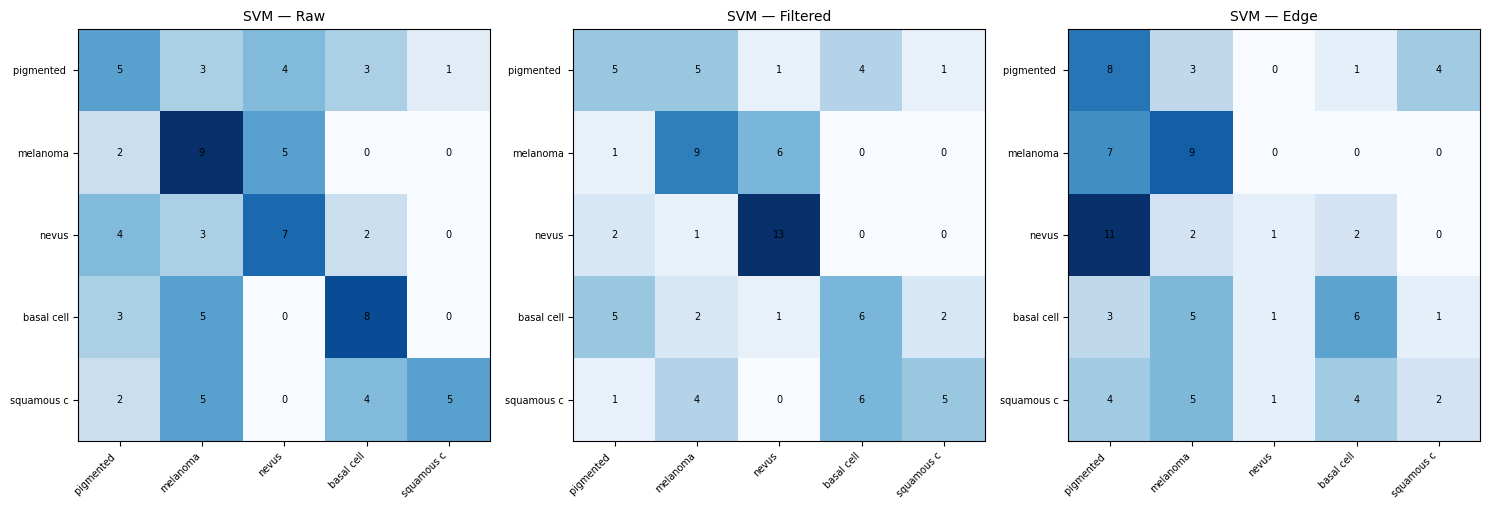

In [23]:
best_model_name = long_df.loc[long_df["Accuracy"].idxmax(), "Model"]
print("Best-performing model overall:", best_model_name)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, variant in zip(axes, ["Raw", "Filtered", "Edge"]):
    cm = conf_matrices[(best_model_name, variant)]
    ax.imshow(cm, cmap="Blues")
    ax.set_title(f"{best_model_name} — {variant}", fontsize=10)
    ax.set_xticks(range(NUM_CLASSES)); ax.set_yticks(range(NUM_CLASSES))
    ax.set_xticklabels([c[:10] for c in SELECTED_CLASSES], rotation=45, ha="right", fontsize=7)
    ax.set_yticklabels([c[:10] for c in SELECTED_CLASSES], fontsize=7)
    for i in range(NUM_CLASSES):
        for j in range(NUM_CLASSES):
            ax.text(j, i, cm[i, j], ha="center", va="center", fontsize=7)
plt.tight_layout()
plt.savefig("task6_confusion_matrices.png", dpi=150)
plt.show()

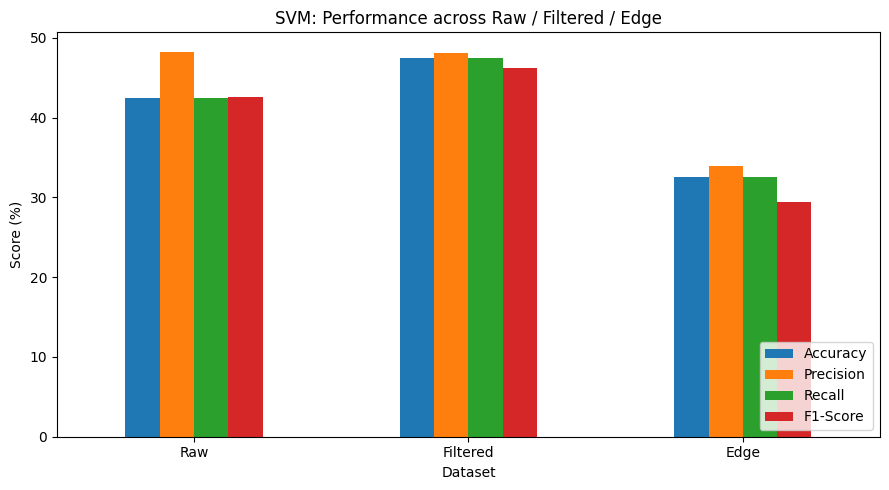

In [24]:
metrics_to_plot = ["Accuracy", "Precision", "Recall", "F1-Score"]
plot_df = long_df[long_df["Model"] == best_model_name].set_index("Dataset")[metrics_to_plot]
plot_df = plot_df.reindex(["Raw", "Filtered", "Edge"])

plot_df.plot(kind="bar", figsize=(9, 5))
plt.title(f"{best_model_name}: Performance across Raw / Filtered / Edge")
plt.ylabel("Score (%)")
plt.xticks(rotation=0)
plt.legend(loc="lower right")
plt.tight_layout()
plt.savefig("task6_performance_bar_chart.png", dpi=150)
plt.show()


In [25]:
table1_df.to_csv("lab03_table1_noise_effect.csv", index=False)
table2_df.to_csv("lab03_table2_canny_params.csv", index=False)
table3_df.to_csv("lab03_table3_classification_comparison.csv", index=False)
long_df.to_csv("lab03_full_results_long.csv", index=False)

export = {f"{m}__{v}": metrics for (m, v), metrics in results.items()}
with open("lab03_all_results.json", "w") as fp:
    json.dump(export, fp, indent=2)

print("Saved: lab03_table1_noise_effect.csv, lab03_table2_canny_params.csv,")
print("       lab03_table3_classification_comparison.csv, lab03_full_results_long.csv,")
print("       lab03_all_results.json")
print("Also saved figures: task1_edge_comparison.png, task1_sobel_components.png,")
print("       task2_noise_examples.png, task2_table1_edge_maps.png, task3_canny_params.png,")
print("       task4_dataset_variants.png, task6_confusion_matrices.png, task6_performance_bar_chart.png")

Saved: lab03_table1_noise_effect.csv, lab03_table2_canny_params.csv,
       lab03_table3_classification_comparison.csv, lab03_full_results_long.csv,
       lab03_all_results.json
Also saved figures: task1_edge_comparison.png, task1_sobel_components.png,
       task2_noise_examples.png, task2_table1_edge_maps.png, task3_canny_params.png,
       task4_dataset_variants.png, task6_confusion_matrices.png, task6_performance_bar_chart.png


Discussion Questions



Q1. Edge Detection and Noise. 
Ans:The Laplacian is theoretically the most noise-sensitive
detector, since it is a second derivative and amplifies high-frequency noise directly;
check your `Noise Sensitivity` column in Table 1 to confirm this held for your images.

Q2. Effect of Filtering.
Ans:Gaussian filtering should suppress Gaussian noise well but
can blur/round fine edges; Median filtering should remove salt-and-pepper noise almost
completely without blurring edges as much, since it isn't a linear low-pass filter.
Compare the "Noisy" vs. "Noisy + Filter" rows in Table 1.

Q3. Canny Parameters. 
Ans: Lower thresholds (e.g. Canny-1) should detect more edges,
including weaker/noisier ones; higher thresholds (Canny-3) should give fewer, stronger,
cleaner edges but may miss faint true boundaries. Check the `Number of Detected Edges`
trend in Table 2.

Q4. Edge Maps and Classification.
Ans:Compare the Accuracy Raw / Accuracy Filtered /
Accuracy Edge columns of Table 3 for each model.

Q5. Information Loss. 
Ans:Edge maps discard texture, color, and absolute intensity —
information that can be diagnostically important for skin lesions (e.g. color
variegation, texture irregularity are ABCDE melanoma criteria), so classifiers relying
only on edges may underperform despite emphasizing shape/boundary.

Q6. Classical vs. Deep Features. 
Ans:A CNN can learn task-optimal, multi-scale,
non-linear edge-like filters jointly with the classifier, rather than being restricted
to one fixed, manually chosen edge operator and threshold — this typically preserves
more useful information than a hard-thresholded binary edge map.

Q7. Best Representation.
Ans:Base this on the Accuracy Raw / Filtered / Edge columns of
your Table 3 — state which representation won overall and for which specific models.